# Olive Cartographer consolidated analysis for manuscript

This notebook replaces the previous two notebooks and resolves the **120 vs 60** issue.

**Data logic**

- The raw CSV contains **120 side-level observations**: 20 rows × 3 longitudinal sections × 2 canopy faces.
- The manuscript should use **60 subsection-level observations**: 20 rows × 3 sections, after combining the two canopy faces.
- This is the correct unit for the paper because production is available/validated after both canopy faces are combined.

The notebook exports the figures used by the LaTeX manuscript and prints manuscript-ready statistics using the final Cartographer terminology.


In [1]:
# Core packages
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

BASE_DIR = Path.cwd()
DATA_FILE = BASE_DIR / 'Atlas_data_new.csv'
FIG_DIR = BASE_DIR / 'figures'
TAB_DIR = BASE_DIR / 'tables'
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', context='paper')
plt.rcParams['figure.dpi'] = 150
# Use same palette as analysis.ipynb for consistent figures
PALETTE = sns.color_palette('deep')

# Manuscript display labels. Internal column names are kept unchanged so the data pipeline remains stable.
DISPLAY_LABELS = {
    'MI_Garcia': 'Cartographer MI',
    'MI_Visual': 'Manual MI',
    'Color Index': 'Cartographer CI',
    'Atlas_estimated_production_kg': 'Cartographer production measure',
    'Measured_production_kg': 'Field-measured production',
}

def label_for(name):
    return DISPLAY_LABELS.get(name, name)


## 1. Load raw side-level data

Place `Elaborate_Roberto_light.csv` in the same folder as this notebook.

Expected raw unit: **one canopy face of one row-section**. Therefore the raw file should have 120 rows.


In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(f'Missing {DATA_FILE.name}. Put it in the same folder as this notebook.')

# Read the raw data from the Excel file.
raw = pd.read_excel(DATA_FILE.with_suffix('.xlsx'), sheet_name='Atlas_data', header=0)
raw.columns = [c.strip() for c in raw.columns]

# Standardise maturity-index column names from the existing files.
rename_map = {
    'M.I. NORM': 'MI_Garcia',
    # 'M.I. Garcia': 'MI_Garcia',
    'M.I. visivo': 'MI_Visual',
    'Produzione plot [kg]': 'Production_plot_kg',
    'Produzione plot somma dei due lati [kg]': 'Atlas_production_both_faces_kg',
    'Produzione plot MISURATA': 'Measured_production_kg',    
}
raw = raw.rename(columns={k:v for k,v in rename_map.items() if k in raw.columns})

print('Raw side-level dataset shape:', raw.shape)
print('Columns:')
print(list(raw.columns))
raw.head()


Raw side-level dataset shape: (120, 20)
Columns:
['Plot', 'Riga', 'frutti/pianta', 'N. frutti', 'Superficie plot [ha]', 'Production_plot_kg', 'Resa [kg/ha]', 'Atlas_production_both_faces_kg', 'Resa somma dei due lati [kg/ha]', 'Measured_production_kg', 'Color Index', 'CL 0', 'CL 1', 'CL 2', 'CL 3', 'CL 4', 'M.I. Garcia', 'MI_Garcia', 'MI_Visual', 'Color Index.1']


,Plot,Riga,frutti/pianta,N. frutti,Superficie plot [ha],Production_plot_kg,Resa [kg/ha],Atlas_production_both_faces_kg,Resa somma dei due lati [kg/ha],Measured_production_kg,Color Index,CL 0,CL 1,CL 2,CL 3,CL 4,M.I. Garcia,MI_Garcia,MI_Visual,Color Index.1
0,1,1,1910,74353,0.02,211.820,6617.4,211.820,13487.238,715.74476,0.62,47,73,30,24,0,2.05,1.18,1.91,0.62
1,1,2,1982,77189,0.02,198.120,6869.8,198.120,NaN,NaN,0.67,46,49,26,42,0,2.27,1.39,2.03,0.67
2,1,3,1320,51392,0.02,149.900,4573.9,149.900,8868.761,541.37522,0.78,17,38,29,84,0,3.48,2.07,2.31,0.78
3,1,4,1246,48257,0.02,174.175,4294.9,174.175,NaN,NaN,0.85,12,20,34,101,0,3.91,2.34,2.31,0.85
4,1,5,1324,51553,0.02,180.400,4588.2,180.400,,645.25172,0.78,28,28,22,85,0,3.27,2.01,2.21,0.78


## 3. Descriptive statistics and ripening-class distribution

In [3]:
raw[['N. frutti', 'Production_plot_kg', 'Color Index', 'MI_Garcia', 'MI_Visual']].describe().round(2)

,N. frutti,Production_plot_kg,Color Index,MI_Garcia,MI_Visual
count,120.00,120.00,120.00,120.00,120.00
mean,75710.51,207.18,0.84,2.42,2.38
std,26184.95,52.08,0.07,0.41,0.18
min,30893.00,122.40,0.61,1.18,1.73
25%,54762.00,174.03,0.81,2.32,2.31
50%,72444.00,196.03,0.85,2.54,2.42
75%,86926.25,223.58,0.89,2.71,2.49
max,160409.00,400.64,0.93,2.94,2.69


Ripening class distribution after aggregating both faces (n=60 subsections):
class percent  detected_fruit
 CL 0     5.4          492982
 CL 1    10.9          990521
 CL 2    21.5         1949661
 CL 3    62.2         5652095
 CL 4     0.0               0
Total Cartographer-detected olives: 9085261


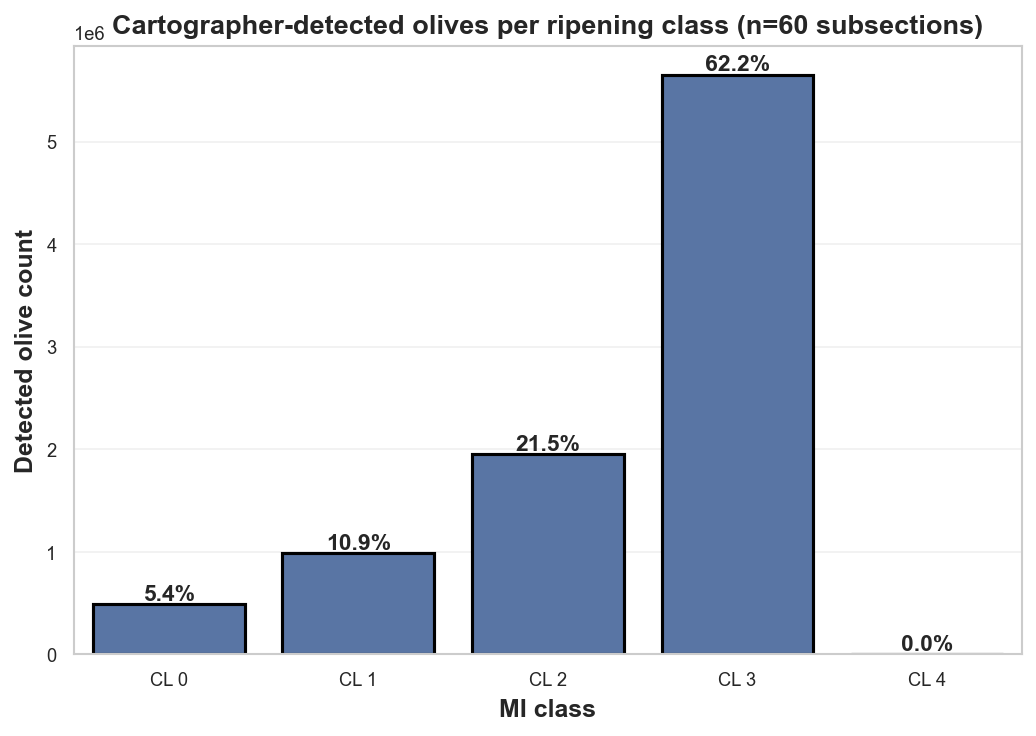

In [4]:
CL_COLS = ['CL 0','CL 1','CL 2','CL 3','CL 4']

class_totals = raw[CL_COLS].sum()
detected_fruit = raw['N. frutti'].sum() if 'N. frutti' in raw.columns else None

class_pct = class_totals / class_totals.sum() * 100
class_detected_fruit = class_pct * detected_fruit / 100 if detected_fruit is not None else None
class_summary = pd.DataFrame({'class': CL_COLS, 'percent': class_pct.values, 'detected_fruit' : class_detected_fruit.values.astype(int)})
class_summary.to_csv(TAB_DIR / 'ripening_class_distribution.csv', index=False)

print('Ripening class distribution after aggregating both faces (n=60 subsections):')
print(class_summary.to_string(index=False, formatters={'percent': '{:.1f}'.format}))
print('Total Cartographer-detected olives:', int(detected_fruit))
    
# Use Seaborn barplot for consistent styling
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x='class', y='detected_fruit', data=class_summary, palette=[PALETTE[0]]*len(class_summary), ax=ax, edgecolor='black', linewidth=1.5)
for i, row in class_summary.iterrows():
    ax.text(i, row['detected_fruit'], f"{row['percent']:.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('MI class', fontsize=12, fontweight='bold')
ax.set_ylabel('Detected olive count', fontsize=12, fontweight='bold')
ax.set_title('Cartographer-detected olives per ripening class (n=60 subsections)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(FIG_DIR / 'corr_fig4_olive_count_per_class.pdf', dpi=300, bbox_inches='tight')
plt.show()


## 4. Correlation matrix on the 120 subsection-level dataset


Correlation dataset n = 120
Cartographer MI vs Manual MI: r=0.9006, p=1.626e-44
Cartographer MI vs Cartographer CI: r=0.9646, p=3.845e-70
Manual MI vs Cartographer CI: r=0.9485, p=9.954e-61


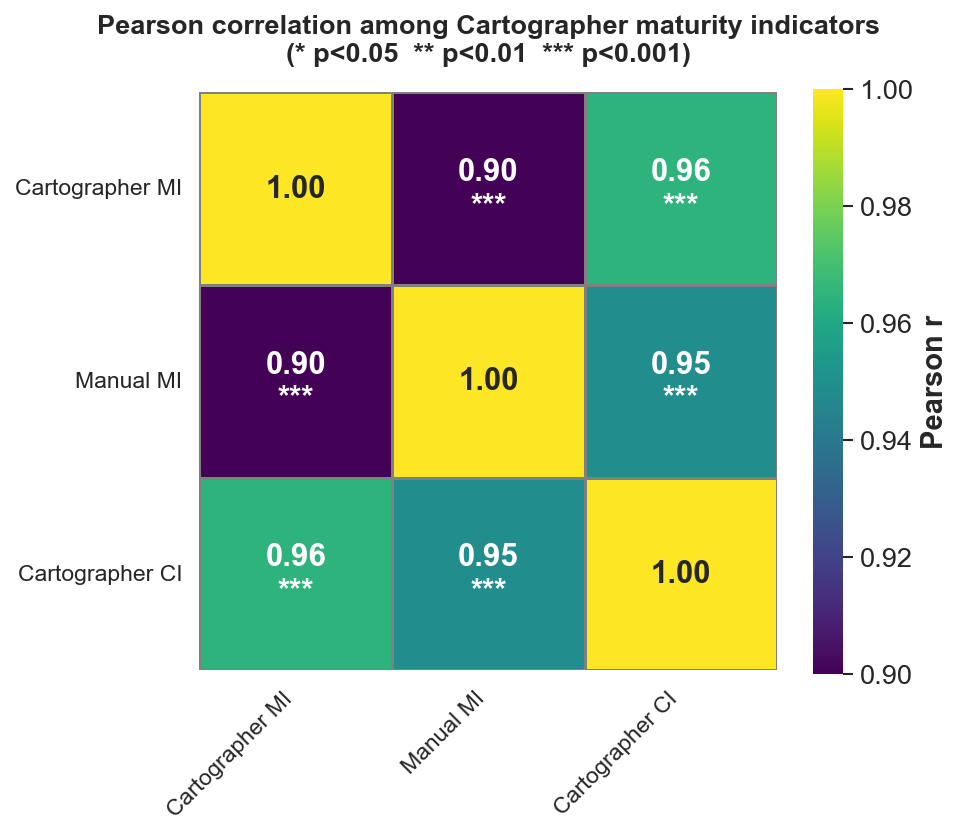

In [5]:
corr_vars = [c for c in ['MI_Garcia','MI_Visual','Color Index'] if c in raw.columns]
if len(corr_vars) < 2:
    raise ValueError('Not enough variables available for correlation analysis.')

data_corr = raw[corr_vars].dropna()
print('Correlation dataset n =', len(data_corr))

r_mat = pd.DataFrame(np.eye(len(corr_vars)), index=corr_vars, columns=corr_vars)
p_mat = pd.DataFrame(np.zeros((len(corr_vars), len(corr_vars))), index=corr_vars, columns=corr_vars)

for i,a in enumerate(corr_vars):
    for j,b in enumerate(corr_vars):
        if i < j:
            r,p = stats.pearsonr(data_corr[a], data_corr[b])
            r_mat.loc[a,b] = r_mat.loc[b,a] = r
            p_mat.loc[a,b] = p_mat.loc[b,a] = p
            print(f'{label_for(a)} vs {label_for(b)}: r={r:.4f}, p={p:.3e}')

# Plot annotated matrix.
def star(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

annot = r_mat.copy().astype(str)
for a in corr_vars:
    for b in corr_vars:
        if a == b:
            annot.loc[a,b] = '1.00'
        else:
            annot.loc[a,b] = f"{r_mat.loc[a,b]:.2f}\n{star(p_mat.loc[a,b])}"

plot_r_mat = r_mat.rename(index=DISPLAY_LABELS, columns=DISPLAY_LABELS)
plot_annot = annot.rename(index=DISPLAY_LABELS, columns=DISPLAY_LABELS)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    plot_r_mat.astype(float),
    annot=plot_annot,
    fmt='',
    center=0.95,
    vmin=0.9,
    vmax=1.0,
    square=True,
    cbar_kws={'label':'Pearson r', 'ticks':[0.90, 0.92, 0.94, 0.96, 0.98, 1.00]},
    cmap='viridis',
    ax=ax,
    annot_kws={"size": 15, "weight": "bold"},
    linewidths=0.5,
    linecolor='gray'
)

ax.set_title(
    "Pearson correlation among Cartographer maturity indicators\n(* p<0.05  ** p<0.01  *** p<0.001)", 
    fontsize=13,
    fontweight="bold",
    pad=15
)

# Increase x/y axis labels
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, rotation=0)

# Increase colorbar font
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=13)
cbar.set_label('Pearson r', fontsize=14, fontweight='bold')

fig.tight_layout()
fig.savefig(FIG_DIR / 'corr_fig1_correlation_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()


## 5. Helper functions for regression, cross-validation and Bland--Altman


In [6]:
def regression_with_cv(df, x_col, y_col, k=5, random_state=42):
    d = df[[x_col, y_col]].dropna().copy()
    X = d[[x_col]].values
    y = d[y_col].values
    model = LinearRegression().fit(X, y)
    pred = model.predict(X)
    r2 = r2_score(y, pred)
    rmse = mean_squared_error(y, pred, squared=False)
    r, p = stats.pearsonr(d[x_col], d[y_col])
    cv = KFold(n_splits=k, shuffle=True, random_state=random_state)
    cv_r2 = cross_val_score(LinearRegression(), X, y, cv=cv, scoring='r2')
    cv_rmse = -cross_val_score(LinearRegression(), X, y, cv=cv, scoring='neg_root_mean_squared_error')
    return {
        'data': d, 'model': model, 'pred': pred,
        'slope': float(model.coef_[0]), 'intercept': float(model.intercept_),
        'r': float(r), 'p': float(p), 'r2': float(r2), 'rmse': float(rmse),
        'cv_r2_mean': float(cv_r2.mean()), 'cv_r2_sd': float(cv_r2.std(ddof=1)),
        'cv_rmse_mean': float(cv_rmse.mean()), 'cv_rmse_sd': float(cv_rmse.std(ddof=1)),
    }


def plot_regression(
    res, x_col, y_col, filename, xlabel, ylabel,
    identity=False, x_log=False, y_log=False,
    force_origin=True,
    zoom_origin=False
):
    d = res['data'].copy()

    if x_log and (d[x_col] <= 0).any():
        raise ValueError(f"x_log=True requires all values in '{x_col}' to be > 0")

    if y_log and (d[y_col] <= 0).any():
        raise ValueError(f"y_log=True requires all values in '{y_col}' to be > 0")

    fig, ax = plt.subplots(figsize=(6.5, 5.2))

    sns.regplot(
        x=x_col,
        y=y_col,
        data=d,
        scatter_kws={
            'alpha': 0.75,
            'color': PALETTE[0],
            's': 55,
            'edgecolor': 'white',
            'linewidth': 0.5
        },
        line_kws={
            'color': PALETTE[1],
            'linewidth': 2.5
        },
        ci=95,
        ax=ax
    )

    if ax.collections:
        ax.collections[0].set_label('Observed')

    if ax.lines:
        ax.lines[0].set_label('Linear fit')

    if x_log:
        ax.set_xscale('log')

    if y_log:
        ax.set_yscale('log')

    # Force the visual origin only on linear axes
    if force_origin and not x_log:
        ax.set_xlim(left=0)

    if force_origin and not y_log:
        ax.set_ylim(bottom=0)

    # Add identity line only when x and y are in the same unit
    if identity:
        if xlabel != ylabel:
            raise ValueError(
                "Identity line is only meaningful when x and y have the same unit."
            )

        mn = min(d[x_col].min(), d[y_col].min())
        mx = max(d[x_col].max(), d[y_col].max())

        if x_log or y_log:
            mn = max(mn, min(d[x_col][d[x_col] > 0].min(), d[y_col][d[y_col] > 0].min()))

        ax.plot(
            [mn, mx],
            [mn, mx],
            linestyle='--',
            color=PALETTE[2],
            linewidth=1.8,
            label='Identity line'
        )

    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')

    ax.set_title(
        f"{ylabel} vs {xlabel}",
        fontsize=13,
        fontweight='bold',
        pad=12
    )

    eq_text = f"y = {res['slope']:.4f}x {res['intercept']:+.4f}"
    stats_text = (
        f"{eq_text}\n"
        f"r = {res['r']:.3f}, p = {res['p']:.3e}\n"
        f"R² = {res['r2']:.3f}"
    )

    ax.text(
        0.05,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
        family='monospace'
    )

    ax.grid(True, alpha=0.25)
    ax.legend(loc='lower right', fontsize=10, frameon=True)

    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()
    
def bland_altman(a, b):
    a = pd.Series(a).astype(float)
    b = pd.Series(b).astype(float)
    d = pd.DataFrame({'a': a, 'b': b}).dropna()
    mean_vals = (d['a'] + d['b']) / 2
    diff_vals = d['a'] - d['b']
    bias = diff_vals.mean()
    sd = diff_vals.std(ddof=1)
    loa_low = bias - 1.96 * sd
    loa_high = bias + 1.96 * sd
    sw = stats.shapiro(diff_vals) if len(diff_vals) >= 3 else (np.nan, np.nan)
    prop_r, prop_p = stats.pearsonr(mean_vals, diff_vals) if len(diff_vals) >= 3 else (np.nan, np.nan)
    return {
        'mean': mean_vals, 'diff': diff_vals,
        'bias': float(bias), 'sd': float(sd), 'loa_low': float(loa_low), 'loa_high': float(loa_high),
        'shapiro_w': float(sw[0]) if not np.isnan(sw[0]) else np.nan, 'shapiro_p': float(sw[1]) if not np.isnan(sw[1]) else np.nan,
        'prop_r': float(prop_r) if not np.isnan(prop_r) else np.nan, 'prop_p': float(prop_p) if not np.isnan(prop_p) else np.nan,
    }


def plot_bland_altman(res, filename, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    sns.scatterplot(x=res['mean'], y=res['diff'], alpha=0.7, color=PALETTE[0], s=60, ax=ax)
    ax.axhline(res['bias'], linewidth=2.5, label=f"bias={res['bias']:.3f}", color='black')
    ax.axhline(res['loa_low'], linestyle='--', label=f"LoA low={res['loa_low']:.3f}", color=PALETTE[3], linewidth=2)
    ax.axhline(res['loa_high'], linestyle='--', label=f"LoA high={res['loa_high']:.3f}", color=PALETTE[3], linewidth=2)
    ax.fill_between(ax.get_xlim(), res['loa_low'], res['loa_high'], color=PALETTE[3], alpha=0.1)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(f"Bland–Altman: {ylabel}", fontsize=13, fontweight='bold', pad=12)
    
    stats_text = f"Bias = {res['bias']:.3f}\nLoA = [{res['loa_low']:.3f}, {res['loa_high']:.3f}]\nShapiro p = {res['shapiro_p']:.3e}\nProp r = {res['prop_r']:.3f}, p = {res['prop_p']:.3e}"
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            family='monospace')
    
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')
    plt.show()


## 6. Regression and agreement: Cartographer detections calibrated to production


Cartographer MI ~ Manual MI
n = 120
Equation: y = 2.0337x -2.4249
Pearson r = 0.9006, p = 1.626e-44, R2 = 0.8111, RMSE = 0.1782
5-fold CV R2 = 0.7636 ± 0.1371
5-fold CV RMSE = 0.1805 ± 0.0233


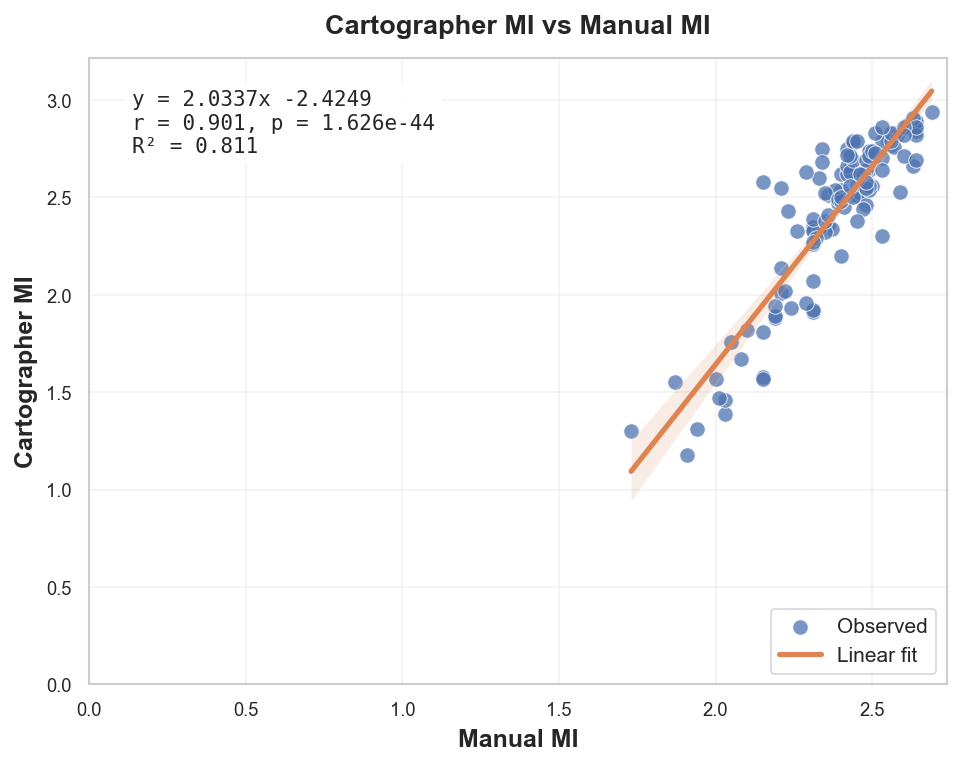

Bland-Altman Cartographer MI - Manual MI
bias = +0.0394, 95% LoA = [-0.4701, 0.5489]
Shapiro-Wilk W = 0.8928, p = 8.574e-08


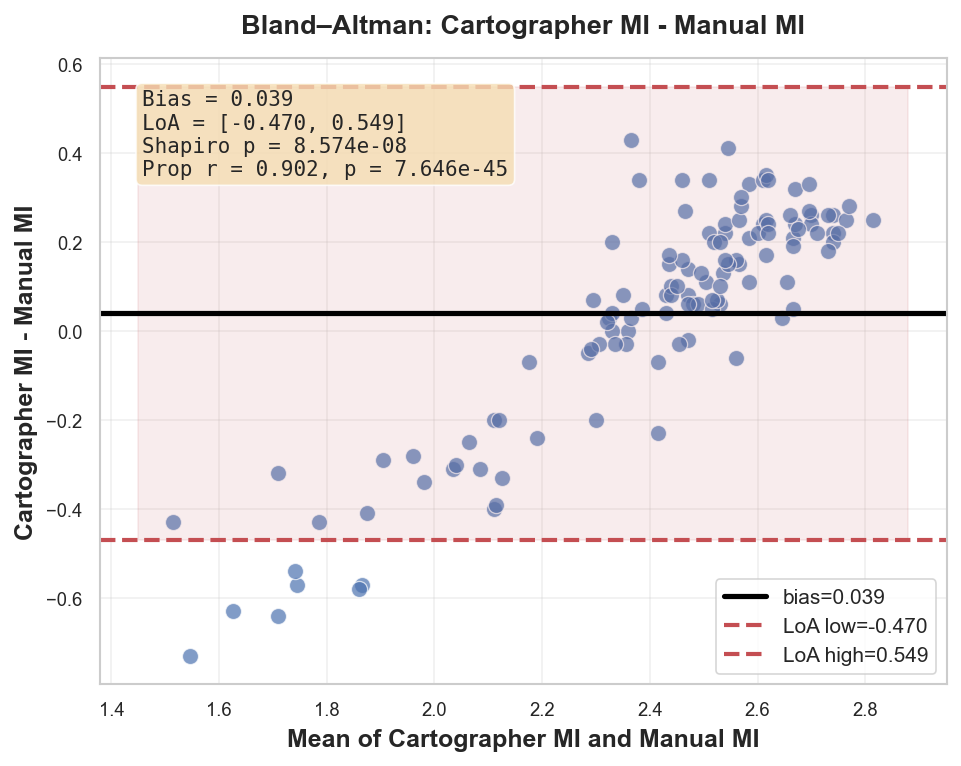

In [7]:
if {'MI_Garcia','MI_Visual'}.issubset(raw.columns):
    res_mi = regression_with_cv(raw, 'MI_Visual', 'MI_Garcia')
    print('Cartographer MI ~ Manual MI')
    print(f"n = {len(res_mi['data'])}")
    print(f"Equation: y = {res_mi['slope']:.4f}x {res_mi['intercept']:+.4f}")
    print(f"Pearson r = {res_mi['r']:.4f}, p = {res_mi['p']:.3e}, R2 = {res_mi['r2']:.4f}, RMSE = {res_mi['rmse']:.4f}")
    print(f"5-fold CV R2 = {res_mi['cv_r2_mean']:.4f} ± {res_mi['cv_r2_sd']:.4f}")
    print(f"5-fold CV RMSE = {res_mi['cv_rmse_mean']:.4f} ± {res_mi['cv_rmse_sd']:.4f}")
    plot_regression(res_mi, 'MI_Visual', 'MI_Garcia', 'corr_fig2_MI_Garcia_vs_Visual_MI.pdf', 'Manual MI', 'Cartographer MI')
    # plot_regression(res_mi, 'MI_Visual', 'MI_Garcia', 'corr_fig2_MI_Garcia_vs_Visual_MI.pdf', 'Manual MI', 'Cartographer MI', identity=True)

    ba_mi = bland_altman(raw['MI_Garcia'], raw['MI_Visual'])
    print('Bland-Altman Cartographer MI - Manual MI')
    print(f"bias = {ba_mi['bias']:+.4f}, 95% LoA = [{ba_mi['loa_low']:.4f}, {ba_mi['loa_high']:.4f}]")
    print(f"Shapiro-Wilk W = {ba_mi['shapiro_w']:.4f}, p = {ba_mi['shapiro_p']:.3e}")
    plot_bland_altman(ba_mi, 'corr_fig5_bland_altman_MI_Garcia_vs_Visual.pdf', 'Mean of Cartographer MI and Manual MI', 'Cartographer MI - Manual MI')


## 7. Regression and agreement: Cartographer production measure vs field-measured production


Production descriptive statistics:
       production_plot_kg  N. frutti
count              120.00     120.00
mean               207.18   75710.51
std                 52.08   26184.95
min                122.40   30893.00
25%                174.03   54762.00
50%                196.03   72444.00
75%                223.58   86926.25
max                400.64  160409.00
Field-measured production ~ Cartographer fruit detections
n = 120
Equation: predicted_production_kg = 0.0019 x detections +64.1165
Pearson r = 0.9501, p = 1.512e-61, R2 = 0.9027, RMSE = 16.1746 kg
5-fold CV R2 = 0.8920 +/- 0.0529
5-fold CV RMSE = 15.7174 +/- 5.3830 kg


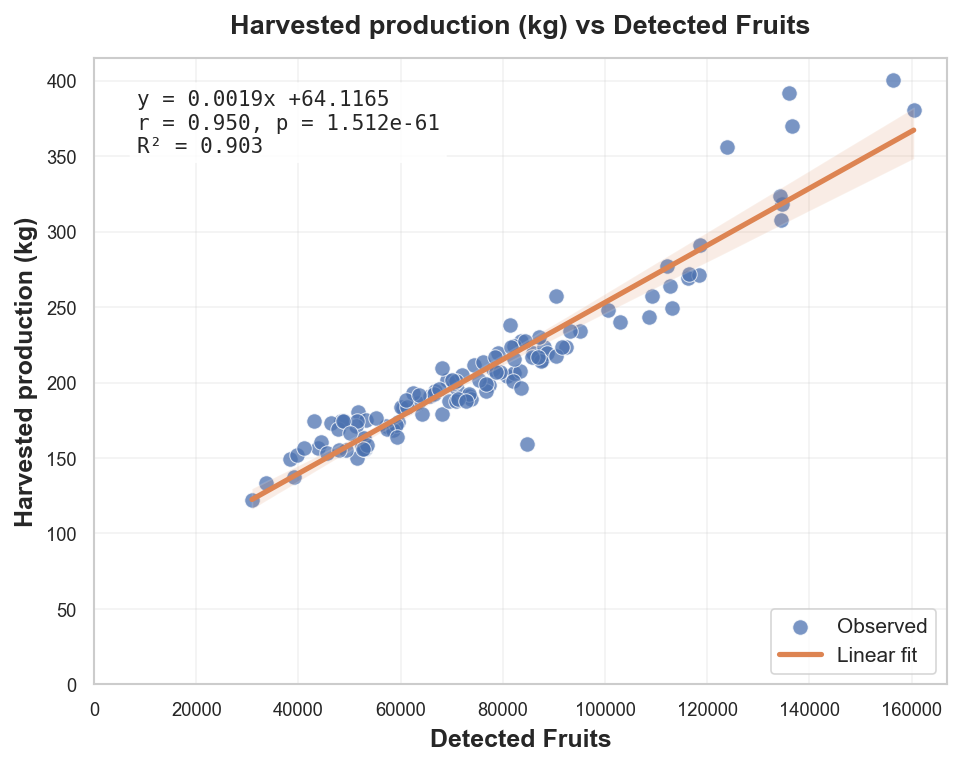

Bland-Altman field-measured production - predicted production from calibration model
bias = -0.00 kg, 95% LoA = [-31.84, 31.84] kg
Proportional bias: r = 0.1620, p = 0.0772


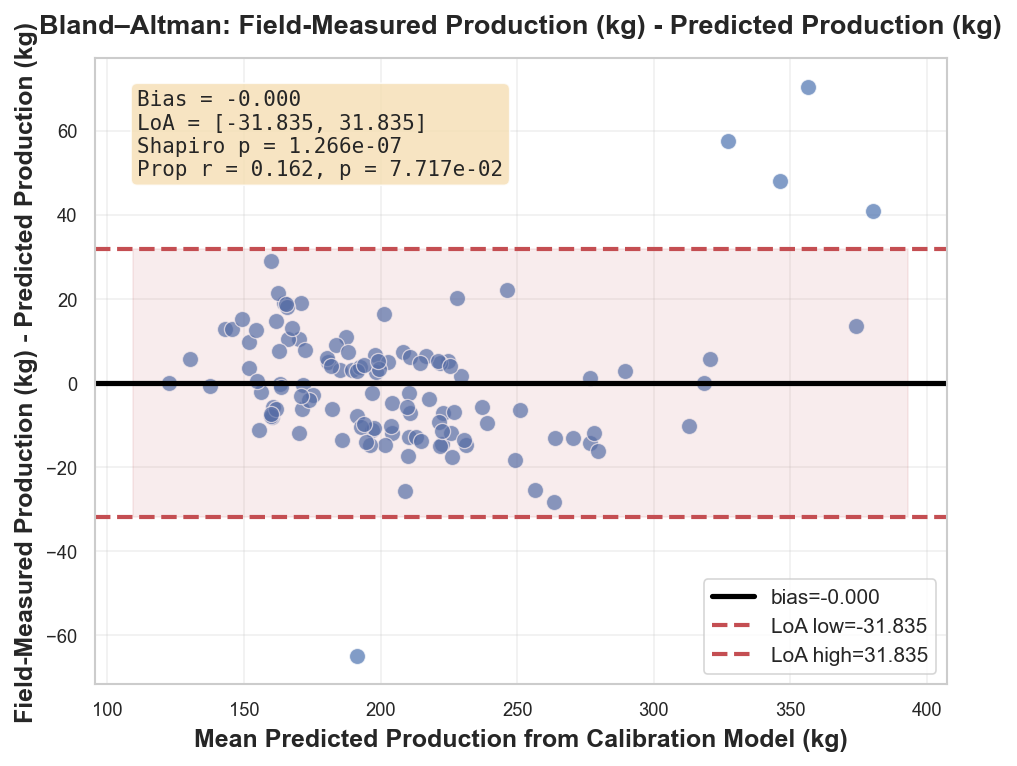

In [8]:
prod = raw[['Production_plot_kg', 'N. frutti']].dropna().copy()
prod = prod.rename(columns={
    'Production_plot_kg': 'production_plot_kg',
    'Detected_Fruits': 'N. frutti'
})
print('Production descriptive statistics:')
print(prod.describe().round(2))
prod.describe().round(3).to_csv(TAB_DIR / 'production_descriptive_statistics.csv')

res_prod = regression_with_cv(prod, 'N. frutti', 'production_plot_kg')
print('Field-measured production ~ Cartographer fruit detections')
print(f"n = {len(res_prod['data'])}")
print(f"Equation: predicted_production_kg = {res_prod['slope']:.4f} x detections {res_prod['intercept']:+.4f}")
print(f"Pearson r = {res_prod['r']:.4f}, p = {res_prod['p']:.3e}, R2 = {res_prod['r2']:.4f}, RMSE = {res_prod['rmse']:.4f} kg")
print(f"5-fold CV R2 = {res_prod['cv_r2_mean']:.4f} +/- {res_prod['cv_r2_sd']:.4f}")
print(f"5-fold CV RMSE = {res_prod['cv_rmse_mean']:.4f} +/- {res_prod['cv_rmse_sd']:.4f} kg")
plot_regression(res_prod, 'N. frutti', 'production_plot_kg', 'corr_fig3_production_estimated_vs_measured.pdf', 'Detected Fruits', 'Harvested production (kg)', identity=False)
# plot_regression(res_prod, 'Detected_Fruits', 'production_plot_kg', 'corr_fig3_production_estimated_vs_measured_identity.pdf', 'Fruit per plant', 'Harvested production (kg)', identity=True, y_log=True, zoom_origin=True)

detections = prod['N. frutti'].astype(float)
measured = prod['production_plot_kg'].astype(float)
predicted = res_prod['model'].predict(detections.to_frame())
ba_prod = bland_altman(measured, predicted)
print('Bland-Altman field-measured production - predicted production from calibration model')
print(f"bias = {ba_prod['bias']:+.2f} kg, 95% LoA = [{ba_prod['loa_low']:.2f}, {ba_prod['loa_high']:.2f}] kg")
print(f"Proportional bias: r = {ba_prod['prop_r']:.4f}, p = {ba_prod['prop_p']:.4f}")
plot_bland_altman(ba_prod, 'corr_fig6_bland_altman_production.pdf', 'Mean Predicted Production from Calibration Model (kg)', 'Field-Measured Production (kg) - Predicted Production (kg)')


## 9. Manuscript-ready numerical summary

In [9]:
print('=== MANUSCRIPT SUMMARY ===')
print(f'Analytical unit: {len(raw)} subsections after aggregating two canopy faces.')
print(f'Raw side-level observations: {len(raw)}.')
print(f'Total Cartographer-detected olives in aggregated dataset: {int(raw[CL_COLS].sum().sum())}.')
print('Ripening classes:')
for _, row in class_summary.iterrows():
    print(f"{row['class']}: {int(row['detected_fruit'])} ({row['percent']:.1f}%)")

if 'res_mi' in globals():
    print('MI regression:')
    print(f"Cartographer MI = {res_mi['slope']:.4f} * Manual MI {res_mi['intercept']:+.4f}; R2={res_mi['r2']:.4f}; RMSE={res_mi['rmse']:.4f}; CV R2={res_mi['cv_r2_mean']:.4f}±{res_mi['cv_r2_sd']:.4f}; CV RMSE={res_mi['cv_rmse_mean']:.4f}±{res_mi['cv_rmse_sd']:.4f}")
    print(f"MI Bland-Altman bias={ba_mi['bias']:+.4f}; LoA=[{ba_mi['loa_low']:.4f}, {ba_mi['loa_high']:.4f}]; Shapiro p={ba_mi['shapiro_p']:.3e}")

if 'res_prod' in globals():
    print('Production regression:')
    print(f"Field-measured production = {res_prod['slope']:.4f} * Cartographer detections {res_prod['intercept']:+.4f}; R2={res_prod['r2']:.4f}; RMSE={res_prod['rmse']:.2f}; CV R2={res_prod['cv_r2_mean']:.4f}±{res_prod['cv_r2_sd']:.4f}; CV RMSE={res_prod['cv_rmse_mean']:.2f}±{res_prod['cv_rmse_sd']:.2f}")
    print(f"Production Bland-Altman field-measured minus predicted production bias={ba_prod['bias']:+.2f} kg; LoA=[{ba_prod['loa_low']:.2f}, {ba_prod['loa_high']:.2f}] kg; proportional bias r={ba_prod['prop_r']:.4f}, p={ba_prod['prop_p']:.4f}")

=== MANUSCRIPT SUMMARY ===
Analytical unit: 120 subsections after aggregating two canopy faces.
Raw side-level observations: 120.
Total Cartographer-detected olives in aggregated dataset: 17950.
Ripening classes:
CL 0: 492982 (5.4%)
CL 1: 990521 (10.9%)
CL 2: 1949661 (21.5%)
CL 3: 5652095 (62.2%)
CL 4: 0 (0.0%)
MI regression:
Cartographer MI = 2.0337 * Manual MI -2.4249; R2=0.8111; RMSE=0.1782; CV R2=0.7636±0.1371; CV RMSE=0.1805±0.0233
MI Bland-Altman bias=+0.0394; LoA=[-0.4701, 0.5489]; Shapiro p=8.574e-08
Production regression:
Field-measured production = 0.0019 * Cartographer detections +64.1165; R2=0.9027; RMSE=16.17; CV R2=0.8920±0.0529; CV RMSE=15.72±5.38
Production Bland-Altman field-measured minus predicted production bias=-0.00 kg; LoA=[-31.84, 31.84] kg; proportional bias r=0.1620, p=0.0772
